# **Tugas Akhir IF5250 Deep Learning**

# **Audio-CRNN-Benchmarking-ESC-50**

||Identitas|
|--|--|
|Nama|Siti Ramadina Goethe K.|
|NIM|15322001|
|Kode Mahasiswa|MHS-06|
|Dataset|[ESC-50](https://github.com/karolpiczak/ESC-50)|

# Bagian 1:  Persiapan Awal

## 1.1 Import Libraries & Setup Random Seed

In [14]:
import os
import sys
import time
import json
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchaudio
import torch.nn.functional as F
import torchaudio.functional as AF
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [17]:
print(f"CUDA avalailable: {torch.cuda.get_device_name(0)}")
print(f"Python: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchaudio: {torchaudio.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print("Setup complete.")

CUDA avalailable: Tesla T4
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch version: 2.10.0+cu128
Torchaudio: 2.10.0+cu128
NumPy: 2.4.6
Pandas: 2.3.3
Matplotlib: 3.10.0
Seaborn: 0.13.2
Scikit-learn: 1.6.1
Setup complete.


## 1.2 Load Dataset ESC-50

In [85]:
# Baca data
csv_path = '/kaggle/input/datasets/mmoreaux/environmental-sound-classification-50/esc50.csv'
wav_dir_path = '/kaggle/input/datasets/mmoreaux/environmental-sound-classification-50/audio/audio'

df = pd.read_csv(csv_path)
print(f"Total data: {len(df)} sampel")
df.head()

Total data: 2000 sampel


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


## 1.3 Konversi File Audio ke Mel-Spectogram

In [86]:
# Konversi ke melspectogram
mel_spectogram = T.MelSpectrogram(
    sample_rate = 22050,
    n_fft = 1024,
    hop_length = 512,
    n_mels = 128,
)

# Ubah audio ke Log-Mel-Spectogram
def log_mel_spec(path):
  waveform, sample_rate = torchaudio.load(path)
  mel_spec = mel_spectogram(waveform)
  log_mel = T.AmplitudeToDB(mel_spec, top_db=80)(mel_spec)
  return log_mel[0]

In [87]:
# Kelas ESC-50 Dataset
class ESC50Dataset(Dataset):
  def __init__(self, df, wav_dir, transform=None, augment=False):
    self.df = df
    self.wav_dir = wav_dir
    self.transform = transform
    self.augment = augment

    # Augmentasi untuk membuat data lebih beragam pada saat training
    if self.augment:
      self.spec_aug = nn.Sequential(
          T.FrequencyMasking(freq_mask_param=15), # hapus freq acak
          T.TimeMasking(time_mask_param=40)       # hapus waktu acak
      )

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    wav_name = self.df.iloc[idx]['filename']
    label = self.df.iloc[idx]['target']
    audio_path = os.path.join(self.wav_dir, wav_name)

    # Ambil mel-spec
    mel_spec = log_mel_spec(audio_path)
    mel_spec = mel_spec.unsqueeze(0) # tambah dimensi channel (1, freq, t)

    # Penerapan augmentasi
    if self.augment:
      mel_spec = self.spec_aug(mel_spec)
    if self.transform:
      mel_spec = self.transform(mel_spec)

    return mel_spec, label

dataset = ESC50Dataset(df, wav_dir_path)

Id: 1126 | Label: 6 | Kategori: hen
Ukuran Tensor Spectogram: torch.Size([1, 128, 431]) (Ch, Mel, t)


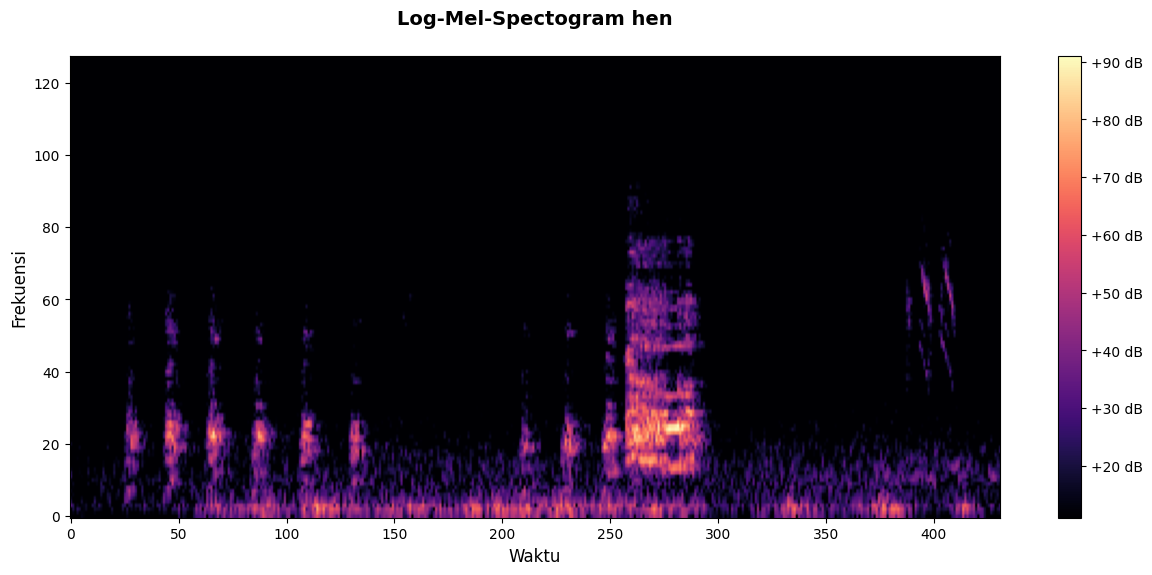

In [88]:
# Contoh representasi visual dari suara (spektorgram)

# Pilih satu sampel acak
idx = np.random.randint(0, len(dataset))
mel, label = dataset[idx]
category = df.iloc[idx]['category']

print(f"Id: {idx} | Label: {label} | Kategori: {category}")
print(f"Ukuran Tensor Spectogram: {mel.shape} (Ch, Mel, t)")

plt.figure(figsize=(15,6))
plt.imshow(mel[0].numpy(), origin='lower', aspect='auto', cmap='magma')
plt.title(f"Log-Mel-Spectogram {category}", fontsize=14, y=1.05, fontweight='bold')
plt.xlabel("Waktu", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)
plt.colorbar(format="%+2.0f dB")
plt.show()

## 1.4 Implementasi 5-Fold Cross-Validation

Fold adalah melakukan partisi data dengan jumlah yang sama besar.

In [89]:
# Implementasi 5-Fold Cross-Validation
# Fold 1-3 train
# Fold 4 validation
# Fold 5 test

train_df = df[df['fold'].isin([1,2,3])].reset_index(drop=True)
val_df = df[df['fold']==4].reset_index(drop=True)
test_df = df[df['fold']==5].reset_index(drop=True)

## 1.5 Data Loader

In [90]:
# DataLoader (Training, Validation, Test)
BATCH_SIZE = 32

train_dataset = ESC50Dataset(train_df, wav_dir_path, augment=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = ESC50Dataset(val_df, wav_dir_path, augment=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = ESC50Dataset(test_df, wav_dir_path, augment=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Jumlah data latih: {len(train_df)}")
print(f"Jumlah data validasi: {len(val_df)}")
print(f"Jumlah data uji: {len(test_df)}")

# Contoh 1 batch
feat, label = next(iter(train_loader))
print(f"Ukurang bacth input: {feat.shape}")
print(f"Ukuran bacth label: {label.shape}")

Jumlah data latih: 1200
Jumlah data validasi: 400
Jumlah data uji: 400
Ukurang bacth input: torch.Size([32, 1, 128, 431])
Ukuran bacth label: torch.Size([32])


In [91]:
# Khusus untuk ViT Audio
# Buat train loader lagi dengan batch yang lebih sedikit
train_loader_vit = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader_vit = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader_vit = DataLoader(test_dataset, batch_size=8, shuffle=False)

feat, label = next(iter(train_loader_vit))
print(f"Ukurang bacth input: {feat.shape}")
print(f"Ukuran bacth label: {label.shape}")

Ukurang bacth input: torch.Size([8, 1, 128, 431])
Ukuran bacth label: torch.Size([8])


# Bagian 2: Arsitektur Model

TODO:
1. Membuat arsitektur model CRNN, ResNet18, dan ViT Audio

## 2.1 Model Utama: CRNN

In [92]:
 # Kelas CNN dan RNN
class CRNN(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers, num_classes=50):
    super(CRNN, self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers

    # Model CNN untuk ekstraksi fitur
    self.cnn = nn.Sequential(
        # Layer 1
        nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # Layer 2
        nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2, padding=1), 

        # Layer 3
        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # Layer 4
        nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

    )

    # Model sekuensial RNN --> GRU
    self.rnn = nn.GRU(
        input_size=256*8,
        hidden_size=128,
        num_layers=2,
        dropout=0.3,
        batch_first=True,
        bidirectional=True
    )

    # Classifier
    self.dropout = nn.Dropout(0.3)
    self.classifier = nn.Linear(hidden_size*2, num_classes)

  def extract_features(self, x):
    # CNN
    x = self.cnn(x)
    x = x.permute(0,3,1,2) # ubaah [batch, ch, f, t] jadi [batch, t, ch, f]
    batch, t, ch, f = x.size()
    x = x.reshape(batch, t, ch*f)

    # RNN
    gru_out, _ = self.rnn(x)
    feat = gru_out[:, -1, :]
    return feat

  def forward(self, x):
    feat = self.extract_features(x)
    feat = self.dropout(feat)
    out = self.classifier(feat)
    return out

crnn_model = CRNN(input_size=64, hidden_size=128, num_layers=2, num_classes=50)
dummy = torch.randn(4,1,128,216)
output = crnn_model(dummy)
print(output.shape)

print(crnn_model)
print(f"bentuk input:{dummy.shape}")
print(f"bentuk output: {output.shape}")

torch.Size([4, 50])
CRNN(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, moment

## 2.2 Model Pembanding 1 (Baseline): ResNet-18

In [93]:
# Adaptasi ResNet-18 untuk input spectogram (1 ch)
class ResNet18(nn.Module):
  def __init__(self, num_classes=50, pretrained=True):
    # Load model dari torchvision
    super(ResNet18, self).__init__()
    self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
    original_conv = self.resnet.conv1
    self.resnet.conv1 = nn.Conv2d(1, 64,
                                  kernel_size = original_conv.kernel_size,
                                  stride = original_conv.stride,
                                  padding = original_conv.padding,
                                  bias = False
                                  )

    with torch.no_grad():
      self.resnet.conv1.weight[:] = original_conv.weight[:, 0:1, :, :]

    num_ft = self.resnet.fc.in_features
    self.resnet.fc = nn.Linear(num_ft, num_classes)

  def forward(self, x):
    return self.resnet(x)

resnet_model = ResNet18(num_classes=50, pretrained=True).to(device)
print(resnet_model)

ResNet18(
  (resnet): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_run

## 2.3 Model Pembanding 2 (SOTA): ViT Audio

In [94]:
class ViTAudio(nn.Module):
    def __init__(self, num_classes=50, pretrained=True):
        super(ViTAudio, self).__init__()

        # Load ViT Base 16
        weights = models.ViT_B_16_Weights.DEFAULT if pretrained else None
        self.vit = models.vit_b_16(weights=weights)

        # Modifikasi output layer
        in_features = self.vit.heads.head.in_features
        self.vit.heads.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        # Resize ke 224x224
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)

        # Ubah ch 1 --> 3
        x = x.repeat(1, 3, 1, 1)
        return self.vit(x)

# Inisialisasi model
vit_model = ViTAudio(num_classes=50, pretrained=True).to(device)
print(vit_model)

ViTAudio(
  (vit): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          (ln_1): LayerNor

# Bagian 3: Training & Validation Pipeline

TODO:
1. Membuat fungsi training umum yang dapat diterapkan pada semua model.
2. Membuat fungsi validasi umum yang dapat diterapkan pada semua model.
3. Membuat contoh loop training untuk semua model.
4. Membuat loop training sekaligus untuk semua model.
4. Visualisasi hasil seluruh pelatihan model.

## 3.1 Fungsi Training

In [96]:
# Fungsi Training Umum
def train(model, loader, criterion, optimizer, device):
  torch.set_grad_enabled(True)
  model.train()
  running_loss = 0.0
  correct = 0
  total = 0

  for batch_idx, (input, target) in enumerate(loader):
    input, target = input.to(device), target.to(device)

    # Mengosongkan gradien
    optimizer.zero_grad()

    # Forward pass (prediksi)
    output = model(input)

    # Menghitung loss
    loss = criterion(output, target)

    # Backward pass
    loss.backward()

    # Perbarui bobot
    optimizer.step()
    running_loss += loss.item()
    _, predicted = torch.max(output.data, 1)
    total += target.size(0)
    correct += (predicted == target).sum().item()

    epoch_loss =  running_loss / total
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

print("Fungsi training untuk 1 epoch telah dibuat.")

Fungsi training untuk 1 epoch telah dibuat.


In [97]:
print(f'status gradien: {torch.is_grad_enabled()}')

status gradien: True


## 3.2 Fungsi Validasi

In [98]:
# Fungsi Validasi Umum
def validate(model, loader, criterion, device):
  model.eval()
  running_loss = 0.0
  correct = 0
  total = 0

  with torch.no_grad():
    for input, target in loader:
      input, target = input.to(device), target.to(device)
      output = model(input)
      loss = criterion(output, target)
      running_loss += loss.item()
      _, predicted = torch.max(output.data, 1)
      total += target.size(0)
      correct += (predicted == target).sum().item()

      loss = running_loss/total
      acc = 100. * correct/total

    return loss, acc

print('Fungsi validasi umum telah dibuat')

Fungsi validasi umum telah dibuat


## 3.4 Loop Training Semua Model

In [99]:
import gc

# Fungsi untuk melihat status memori dalam MB
def check_gpu_mem():
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated(0) / (1024**2) # Konversi ke MB
        reserved = torch.cuda.memory_reserved(0) / (1024**2)
        print(f"GPU Memory Allocated: {allocated:.2f} MB")
        print(f"GPU Memory Reserved:  {reserved:.2f} MB")

print("--- Sebelum Pembersihan ---")
check_gpu_mem()

# Proses Pembersihan
gc.collect()
torch.cuda.empty_cache()

print("\n--- Setelah Pembersihan ---")
check_gpu_mem()

--- Sebelum Pembersihan ---
GPU Memory Allocated: 902.98 MB
GPU Memory Reserved:  1680.00 MB

--- Setelah Pembersihan ---
GPU Memory Allocated: 900.98 MB
GPU Memory Reserved:  1680.00 MB


In [100]:
all_model_types = ['CRNN', 'ResNet18']
epochs = 50

# All history to store all each model results
all_history = {
    'CRNN': {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []},
    'ResNet18': {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
}

# Loop training for each model
for model in all_model_types:
  print("="*90)
  print(f"Training {model} model")
  print("="*90)

  current_best_val_acc = 0.0

  if model == 'CRNN':
    curr_model = CRNN(input_size=64, hidden_size=128, num_layers=2, num_classes=50).to(device)
  else: # model == 'ResNet18':
    curr_model = ResNet18(num_classes=50, pretrained=True).to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(curr_model.parameters(), lr=1e-3)

  # Loop utama
  for epoch in range(epochs):
    train_loss, train_acc = train(curr_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(curr_model, val_loader, criterion, device)

    all_history[model]['train_loss'].append(train_loss)
    all_history[model]['train_acc'].append(train_acc)
    all_history[model]['val_loss'].append(val_loss)
    all_history[model]['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.2f} | Val loss: {val_loss:.4f} | Val acc: {val_acc:.2f} |")

    # Simpan checkpoint model terbaik untuk model saat ini
    if val_acc > current_best_val_acc:
      current_best_val_acc = val_acc
      torch.save(curr_model.state_dict(), f'{model}_best_model.pth')
      print(f"Model {model} terbaik disimpan.")

del curr_model
torch.cuda.empty_cache()

Training CRNN model
Epoch 1/50 | Train loss: 0.1215 | Train acc: 6.25 | Val loss: 0.1268 | Val acc: 2.00 |
Model CRNN terbaik disimpan.
Epoch 2/50 | Train loss: 0.1192 | Train acc: 12.50 | Val loss: 0.1266 | Val acc: 2.75 |
Model CRNN terbaik disimpan.
Epoch 3/50 | Train loss: 0.1169 | Train acc: 9.38 | Val loss: 0.1263 | Val acc: 3.50 |
Model CRNN terbaik disimpan.
Epoch 4/50 | Train loss: 0.1222 | Train acc: 12.50 | Val loss: 0.1259 | Val acc: 4.00 |
Model CRNN terbaik disimpan.
Epoch 5/50 | Train loss: 0.1173 | Train acc: 3.12 | Val loss: 0.1254 | Val acc: 3.00 |
Epoch 6/50 | Train loss: 0.1207 | Train acc: 9.38 | Val loss: 0.1248 | Val acc: 3.50 |
Epoch 7/50 | Train loss: 0.1208 | Train acc: 0.00 | Val loss: 0.1242 | Val acc: 3.75 |
Epoch 8/50 | Train loss: 0.1174 | Train acc: 6.25 | Val loss: 0.1235 | Val acc: 4.00 |
Epoch 9/50 | Train loss: 0.1165 | Train acc: 6.25 | Val loss: 0.1231 | Val acc: 4.25 |
Model CRNN terbaik disimpan.
Epoch 10/50 | Train loss: 0.1212 | Train acc: 6.25

In [101]:
# Fungsi training khusus ViT

#  Loop Utama untuk ViT
vit_model = ViTAudio(num_classes=50, pretrained=True).to(device)
vit_optimizer = optim.Adam(vit_model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()
epochs = 15
best_val_acc = 0.0

# Jalankan training menggunakan fungsi yang sama
vit_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("="*90)
print(f"Training ViT Audio model")
print("="*90)

for epoch in range(epochs):
    train_loss, train_acc = train(vit_model, train_loader_vit, criterion, vit_optimizer, device)
    val_loss, val_acc = validate(vit_model, val_loader_vit, criterion, device)

    # Simpan ke history vit
    vit_history['train_loss'].append(train_loss)
    vit_history['train_acc'].append(train_acc)
    vit_history['val_loss'].append(val_loss)
    vit_history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.2f} | Val loss: {val_loss:.4f} | Val acc: {val_acc:.2f} |")

    # Simpan model terbaik
    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(vit_model.state_dict(), 'vit_best_model.pth')
      print("Model ViT terbaik disimpan.")

Training ViT Audio model
Epoch 1/15 | Train loss: 0.4884 | Train acc: 0.00 | Val loss: 0.4989 | Val acc: 3.00 |
Model ViT terbaik disimpan.
Epoch 2/15 | Train loss: 0.4800 | Train acc: 12.50 | Val loss: 0.4987 | Val acc: 3.25 |
Model ViT terbaik disimpan.
Epoch 3/15 | Train loss: 0.4987 | Train acc: 0.00 | Val loss: 0.4982 | Val acc: 3.25 |
Epoch 4/15 | Train loss: 0.4924 | Train acc: 0.00 | Val loss: 0.4978 | Val acc: 3.25 |
Epoch 5/15 | Train loss: 0.4793 | Train acc: 0.00 | Val loss: 0.4972 | Val acc: 3.00 |
Epoch 6/15 | Train loss: 0.4935 | Train acc: 0.00 | Val loss: 0.4963 | Val acc: 3.25 |
Epoch 7/15 | Train loss: 0.4677 | Train acc: 0.00 | Val loss: 0.4956 | Val acc: 3.50 |
Model ViT terbaik disimpan.
Epoch 8/15 | Train loss: 0.4899 | Train acc: 12.50 | Val loss: 0.4947 | Val acc: 3.25 |
Epoch 9/15 | Train loss: 0.4596 | Train acc: 12.50 | Val loss: 0.4941 | Val acc: 2.75 |
Epoch 10/15 | Train loss: 0.5002 | Train acc: 0.00 | Val loss: 0.4932 | Val acc: 2.25 |
Epoch 11/15 | Tra

## 3.5 Visualisasi Hasil Training dan Validasi

In [102]:
# Fungsi Visualisasi Kurva Pelatihan (Loss dan Akurasi)

def history_plot(history, model_name):
  epochs = range(1, len(history['train_loss'])+1)

  # Loss vs Epoch
  fig, axes = plt.subplots(1, 2, figsize=(12,5))
  axes[0].plot(epochs, history['train_loss'], label='Train Loss')
  axes[0].plot(epochs, history['val_loss'], label='Validation Loss')
  axes[0].set_title(f'Loss vs Epoch {model_name} Model', fontweight='bold', fontsize=14)
  axes[0].set_xlabel('Epoch')
  axes[0].set_ylabel('Loss')
  axes[0].legend()
  axes[0].grid(True, alpha=0.3)

  # Accuracy vs Epoch
  axes[1].plot(epochs, history['train_acc'], label='Train Accuracy')
  axes[1].plot(epochs, history['val_acc'], label='Validation Accuracy')
  axes[1].set_title(f'Accuracy vs Epoch {model_name} Model', fontweight='bold', fontsize=14)
  axes[1].set_xlabel('Epoch')
  axes[1].set_ylabel('Accuracy')
  axes[1].legend()
  axes[1].grid(True, alpha=0.3)

  fig.savefig(f"{model_name}_train_val_curve.png")
  plt.tight_layout()
  plt.show()

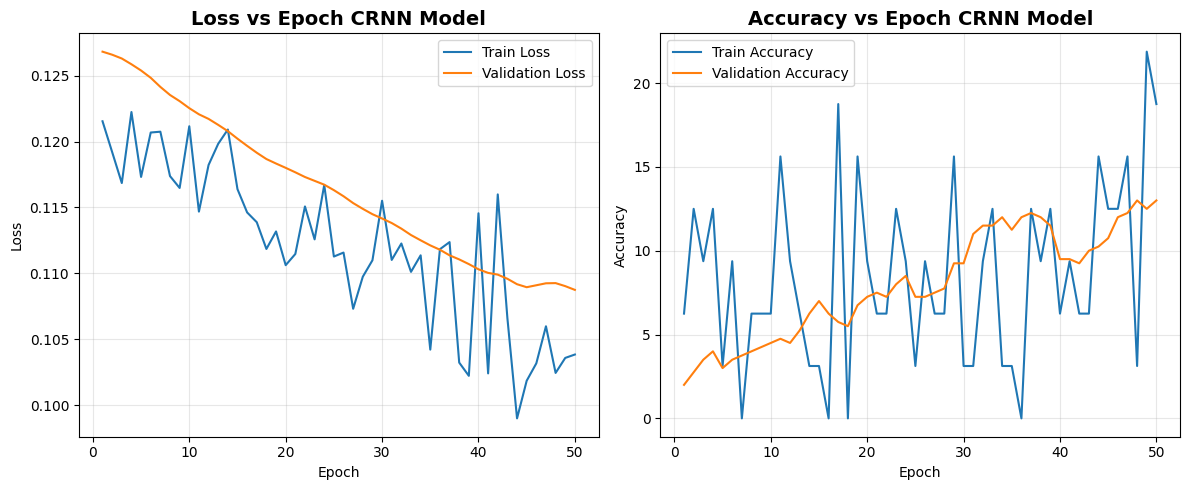

None

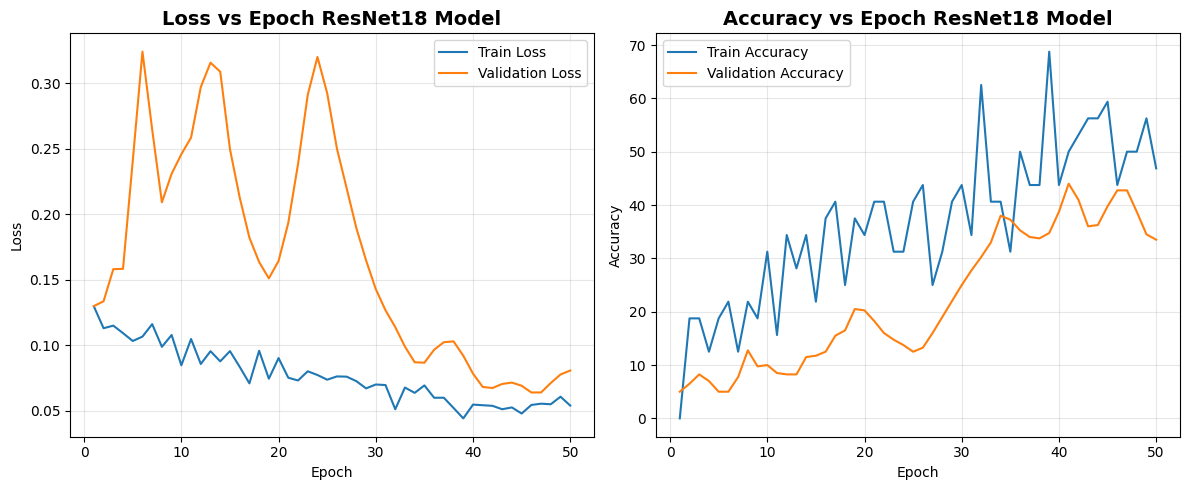

None

In [103]:
# Visualisasi seluruh model
all_model_types = ['CRNN', 'ResNet18']

for model_name in all_model_types:
    vis_model = history_plot(all_history[model_name], model_name)
    display(vis_model)

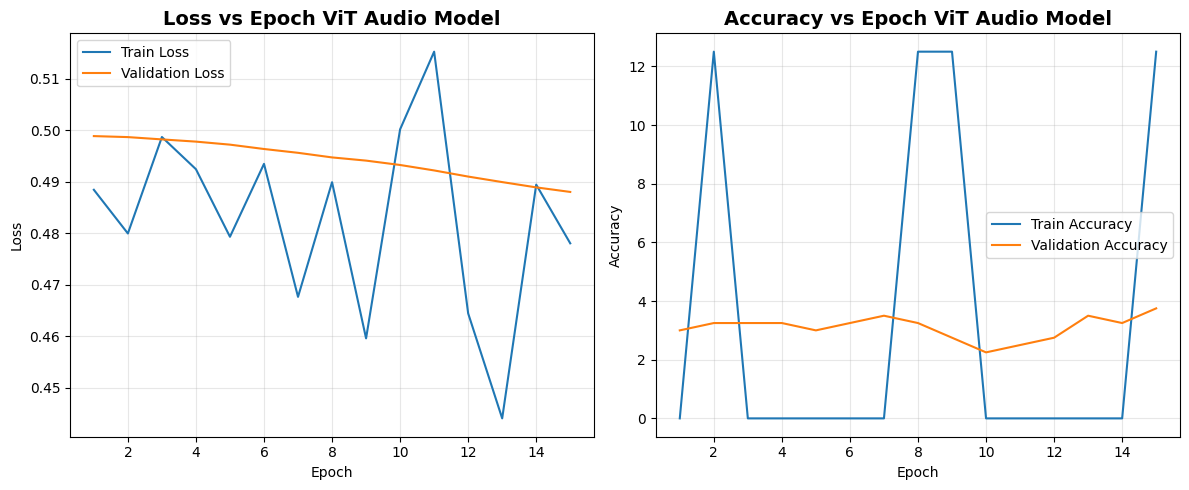

None

In [104]:
vis_vit = history_plot(vit_history, "ViT Audio")
display(vis_vit)

# Bagian 4: Evaluasi dan Benchmarking

TODO:
1. Evaluasi semua model pada Test Set (Fold 5).
2. Hitung Accuracy, Precision, Recall, F1-Score (Weighted). --> Classification Report
3. Buat Confusion Matrix untuk ketiga model.
4. Ekspor hasil ke file metrics.json.

## 4.1 Fungsi Evaluasi

In [105]:
# Fungsi Evaluasi (Testing) Umum
def evaluate(model, loader, criterion, device):
  model.eval()
  all_preds, all_labels = [], []
  total_loss = 0.0
  total_correct = 0
  total_samples = 0

  with torch.no_grad():
    for inputs, targets in loader:
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs)
      loss = criterion(output, targets)

      total_loss += loss.item()*targets.size(0)
      _, pred = output.max(1)
      total_correct += (pred == targets).sum().item()
      total_samples += targets.size(0)

      all_preds.extend(pred.cpu().numpy())
      all_labels.extend(targets.cpu().numpy())

  avg_loss = total_loss / total_samples
  accuracy = 100. * total_correct / total_samples

  return avg_loss, accuracy, all_preds, all_labels

print("Fungsi evaluasi telah dibuat.")

Fungsi evaluasi telah dibuat.


## 4.2 Fungsi Visualisasi Confusion Matrix

In [106]:
# Confusion Matrix Visualisation

def CMVis(cm, classes, model_name):
  # Normalize percente
  cm_norm = cm.astype('float')/ cm.sum(axis=1)[:, np.newaxis]
  plt.figure(figsize=(22,20))
  classes = df.sort_values('target')['category'].unique()

  # Heatmap
  sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues', xticklabels=classes, yticklabels=classes, annot_kws={"size":7}, cbar=True)
  plt.title(f'Confusion Matrix {model_name} Model', fontsize=20, fontweight='bold')
  plt.xlabel('Predicted Labels')
  plt.ylabel('True Labels')
  plt.grid(True, alpha=0.3)

  # Label position
  plt.xticks(rotation=90)
  plt.yticks(rotation=0)

  plt.tight_layout()
  plt.savefig(f"{model_name}_confusion_matrix.png", dpi=300)
  plt.show()

print("Fungsi visualisasi confusion matrix telah dibuat.")

Fungsi visualisasi confusion matrix telah dibuat.


## 4.3 Fungsi Pendukung untuk Evaluasi


In [107]:
# Fungsi untuk hitung params dan waktu inferensi
def get_model_info(model, test_loader, device):
  num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
  model.eval()

  start_time = time.time()
  with torch.no_grad():
    for inputs, targets in test_loader:
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs)
      _, pred = output.max(1)
  end_time = time.time()

  d_time = end_time - start_time
  inf_time = d_time / inputs.size(0) * 1000

  return num_params, inf_time
    
print("Fungsi untuk memperoleh waktu inferensi dan jumlah parameter telah dibuat.")

Fungsi untuk memperoleh waktu inferensi dan jumlah parameter telah dibuat.


In [108]:
# Fungsi persiapan untuk ekspor ke metric.json
def metrics(model_name, acc, f1, best_epoch, model, test_loader, device):
  num_params, inf_time = get_model_info(model, test_loader, device)

  # Spesifikasi file metric.json
  metrics_data = {
      "model_name": model_name,
      "dataset": "ESC-50",
      "subset": "All 50 classes",
      "random_seed": 42,
      "optimizer": "Adam",
      "learning_rate": 0.001,
      "batch_size": 32,
      "epochs_total": 50,
      "best_epoch": best_epoch,
      "test_accuracy": round(acc/100, 4),
      "test_f1_weighted" : round(f1, 4),
      "num_parameters": num_params,
      "inference_time": round(inf_time, 4)
  }

  file_path = f"{model_name}_metrics.json"
  with open(file_path, 'w') as json_file:
    json.dump(metrics_data, json_file, indent=4)

  print(f"Complete saved file in {file_path}")

print("Complete made metrics function")

Complete made metrics function


# Bagian 5: Representational Similarity Analysis (RSM)

TODO:
1. Load "Benchmark Set" berisi 400 audio.
2. Mengekstrak embedding dari penultimate layer untuk setiap model.
3. Menghitung Cosine Similarity Matrix (N x N).
4. Visualisasi heatmap RSM dan menyimpannya dalam .png.

## 5.1 Benchmark Set

Ketentuan:
- 50 kelas
- 8 audio/kelas
- Total 400 audio
- 200 dari fold-4
- 200 dari fold-5

In [109]:
# Fungsi untuk memilih 400 sampel
def benchmark_sampling(all_df):
  df_selected = all_df[all_df['fold'].isin([4,5])] # hanya fold 4 dan 5
  benchmark_list = []
  classes = 50

  # 8 sampel per kelas
  for cls in range(classes):
    sample_fold4 = df_selected[(df_selected['fold'] == 4) &
                               (df_selected['target'] == cls)].head(4) # ambil 4 sampel
    sample_fold5 = df_selected[(df_selected['fold'] == 5) &
                               (df_selected['target'] == cls)].head(4) # ambil 4 sampel

    benchmark_list.append(sample_fold4)
    benchmark_list.append(sample_fold5)

  benchmark_df = pd.concat(benchmark_list).reset_index(drop=True)
  return benchmark_df

# Menjalankan fungsi sampling
benchmark_df = benchmark_sampling(df)

# Buat loader lagi
benchmark_dataset = ESC50Dataset(benchmark_df, wav_dir_path, augment=False)
benchmark_loader = DataLoader(benchmark_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Buat loader khusus ViT dengan batch size yang lebih kecil
benchmark_loader_vit = DataLoader(benchmark_dataset, batch_size=8, shuffle=False)

print("Dataset audio untuk benchmark sudah siap.")

Dataset audio untuk benchmark sudah siap.


## 5.2 Ekstrak Embedding dari Penultimate Layer

In [110]:
# Fungsi ekstrak embedding
def extract_embedding(model, loader, model_type, device):
  model.eval()
  embeddings = []
  labels = []

  with torch.no_grad():
    for inputs, targets in loader:
      inputs = inputs.to(device)

      # Ekstraksi untuk CRNN
      if model_type == 'CRNN':
        feat = model.extract_features(inputs)
        feat = feat.view(feat.size(0), -1) # output terakhir lstm

      # Ekstraksi untuk ResNet18
      elif model_type == 'ResNet18':
        x = model.resnet.conv1(inputs)
        x = model.resnet.bn1(x)
        x = model.resnet.relu(x)
        x = model.resnet.maxpool(x)
        x = model.resnet.layer1(x)
        x = model.resnet.layer2(x)
        x = model.resnet.layer3(x)
        x = model.resnet.layer4(x)
        feat = model.resnet.avgpool(x)
        feat = torch.flatten(feat, 1) # ambil stlh global avg pool

      # Ekstraksi untuk ViT
      elif model_type == 'ViTAudio':
        x = torch.nn.functional.interpolate(inputs, size=(224, 224), mode='bilinear')
        x = x.repeat(1,3,1,1)
        feat = model.vit._process_input(x)
        n = feat.shape[0]
        cls_token = model.vit.class_token.expand(n, -1, -1)
        feat = torch.cat((cls_token, feat), dim=1)
        feat = model.vit.encoder(feat)
        feat = feat[:, 0] # ambil token CLS

      embeddings.append(feat.cpu().numpy())
      labels.append(targets.numpy())

  return np.concatenate(embeddings), np.concatenate(labels)

print("Fungsi ekstraksi embedding telah dibuat.")

Fungsi ekstraksi embedding telah dibuat.


## 5.4 Cosine Similarity & Representation Similarity Analysis

In [111]:
def process_and_save_rsm(embeddings, model_name):
  emb_df = pd.DataFrame(embeddings)
  emb_df.to_csv(f"benchmark_embeddings_{model_name.lower()}.csv", index=False)
  print(f"Embeddings saved to benchmark_embeddings_{model_name.lower()}.csv (Ukuran: {embeddings.shape})")

  rsm_matrix = cosine_similarity(embeddings)
  rsm_df = pd.DataFrame(rsm_matrix)
  rsm_df.to_csv(f"rsm_cosine_{model_name.lower()}.csv", index=False)
  print(f"RSM saved to rsm_cosine_{model_name.lower()}.csv (Ukuran: {rsm_matrix.shape})")

  # Visualisasi heatmap
  plt.figure(figsize=(10,8))
  sns.heatmap(rsm_matrix, annot=True, fmt='.1f', cmap='viridis', vmin=0, vmax=1, xticklabels=False, yticklabels=False)
  plt.title(f'Representation Similarity Matrix of {model_name} Model')

  plt.savefig(f"rsm_heatmap_{model_name.lower()}.png", dpi=300)
  plt.show()
  print(f"Heatmap saved to rsm_heatmap_{model_name.lower()}.png")

  return rsm_matrix
    
print("Fungsi perhitungan cosine similarity dan RSM telah dibuat.")

Fungsi perhitungan cosine similarity dan RSM telah dibuat.


# Bagian 6: Visualisasi Saliency dan Attention

TODO:
1. Pilih 20-30 sampel dari benchmark set.
2. Implementasi Saliency Map (untuk CRNN/ResNet) dan Attention Map (untuk ViT).
3. Simpan visualisasi untuk dibandingkan di laporan.

In [112]:
# Fungsi Visualisasi Saliency/Attention

def sal_attn_visualization(model, loader, model_type, device, num_samples=20):
    if model_type == 'CRNN':
        model.train()
    else: # ResNet-18
        model.eval()
    
    torch.set_grad_enabled(True) # gradien aktif untuk saliency
    os.makedirs(f"saliency_{model_type.lower()}/", exist_ok=True)
    
    with torch.enable_grad():
        for i, (inputs, targets) in enumerate(loader):
          if i >= num_samples:
            break
        
          inputs = inputs.to(device)
          inputs.requires_grad_()
        
          # Forward pass
          outputs = model(inputs)
          target_class = targets[0].item()
          score = outputs[0, target_class]
        
          # Backward pass
          model.zero_grad()
          score.backward()
        
          # Gradient exist check
          if inputs.grad is not None:
            # Saliency Map
            saliency, _ = torch.max(torch.abs(inputs.grad), dim=1)
        
            # Plot
            vis_map = saliency[0].cpu().detach().numpy()
            vis_map = (vis_map - vis_map.min()) / (vis_map.max() - vis_map.min() + 1e-8)
            
            ori = inputs[0,0].detach().cpu().numpy()
        
            plt.figure(figsize=(10,4))
            plt.subplot(1,2,1)
            plt.imshow(ori, cmap='viridis', origin='lower', aspect='auto')
            plt.title(f'Original Audio (Class: {target_class})')
            plt.axis('off')
        
            plt.subplot(1,2,2)
            plt.imshow(vis_map, cmap='hot', origin='lower', aspect='auto')
            plt.title(f'Saliency Map of {model_type}')
        
            plt.tight_layout()
            plt.savefig(f"{i}_{model_type.lower()}_saliency.png")
            plt.close()
          else:
            print(f"No gradient found for sample {i}.")
    
    torch.set_grad_enabled(False)
    
print("Fungsi visualisasi saliency sudah dibuat.")

Fungsi visualisasi saliency sudah dibuat.


# Bagian 7: Hasil Evaluasi Seluruh Kinerja Model


Classification Report:
Model: CRNN
Loss : 3.3777
Accuracy: 11.75%
F1-score: 0.07
              precision    recall  f1-score   support

           0       0.31      0.50      0.38         8
           1       0.00      0.00      0.00         8
           2       0.00      0.00      0.00         8
           3       0.00      0.00      0.00         8
           4       0.06      0.12      0.08         8
           5       0.00      0.00      0.00         8
           6       1.00      0.38      0.55         8
           7       0.00      0.00      0.00         8
           8       0.00      0.00      0.00         8
           9       0.00      0.00      0.00         8
          10       0.17      0.62      0.27         8
          11       0.00      0.00      0.00         8
          12       0.00      0.00      0.00         8
          13       0.00      0.00      0.00         8
          14       0.00      0.00      0.00         8
          15       0.00      0.00      0.00         8

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

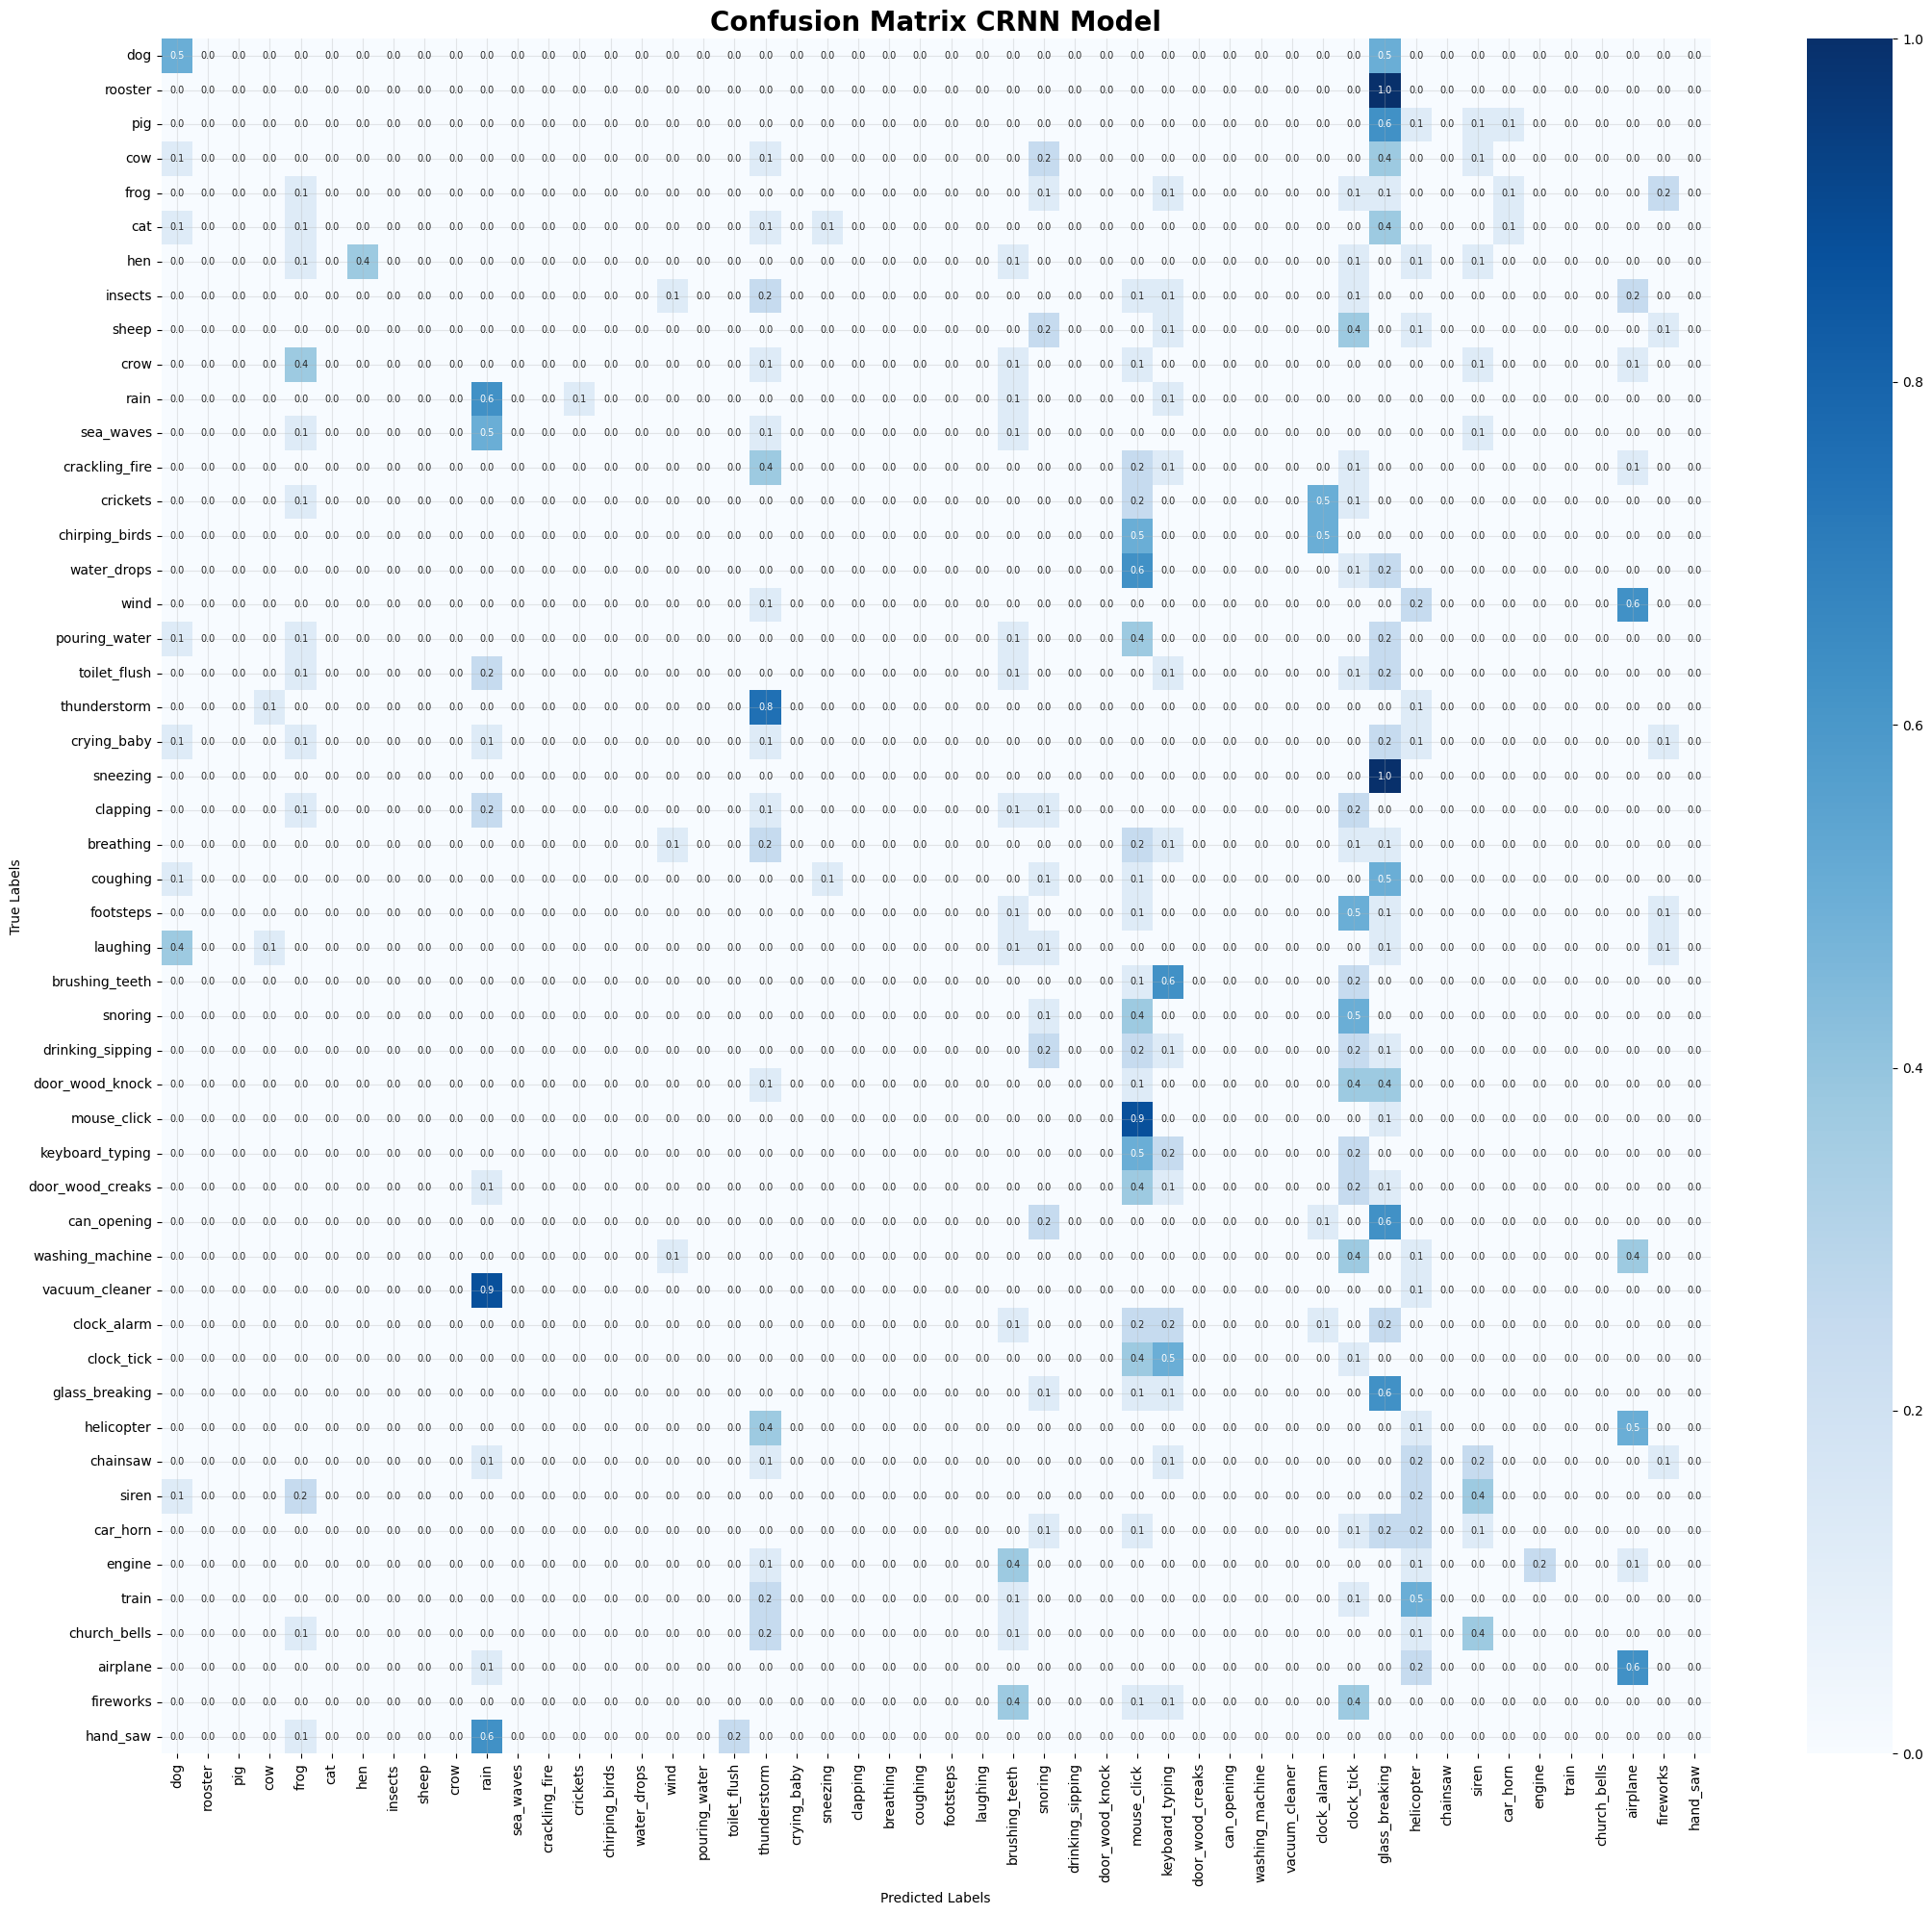

Complete saved file in CRNN_metrics.json
Completed processing metrics for CRNN
Completed extract embedding from penultimate layer of CRNN model
Embeddings saved to benchmark_embeddings_crnn.csv (Ukuran: (400, 256))
RSM saved to rsm_cosine_crnn.csv (Ukuran: (400, 400))


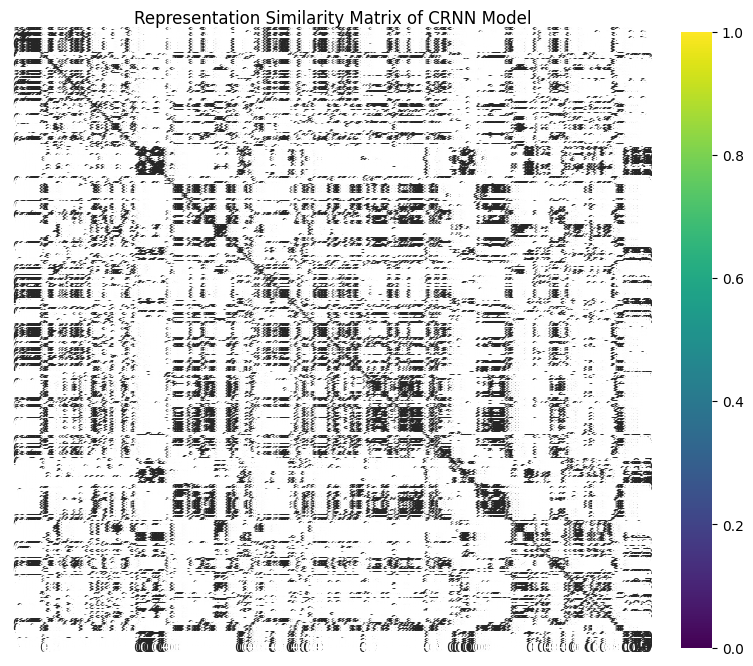

Heatmap saved to rsm_heatmap_crnn.png
Completed process of RSM calculation for CRNN model
Generating visualisation for CRNN
Completed visualisation for CRNN

Classification Report:
Model: ResNet18
Loss : 2.4807
Accuracy: 38.25%
F1-score: 0.33
              precision    recall  f1-score   support

           0       0.43      0.38      0.40         8
           1       0.67      1.00      0.80         8
           2       0.15      0.38      0.21         8
           3       0.40      0.50      0.44         8
           4       0.00      0.00      0.00         8
           5       0.00      0.00      0.00         8
           6       0.21      0.75      0.32         8
           7       1.00      0.38      0.55         8
           8       0.00      0.00      0.00         8
           9       0.00      0.00      0.00         8
          10       0.54      0.88      0.67         8
          11       0.00      0.00      0.00         8
          12       0.33      0.25      0.29         8


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

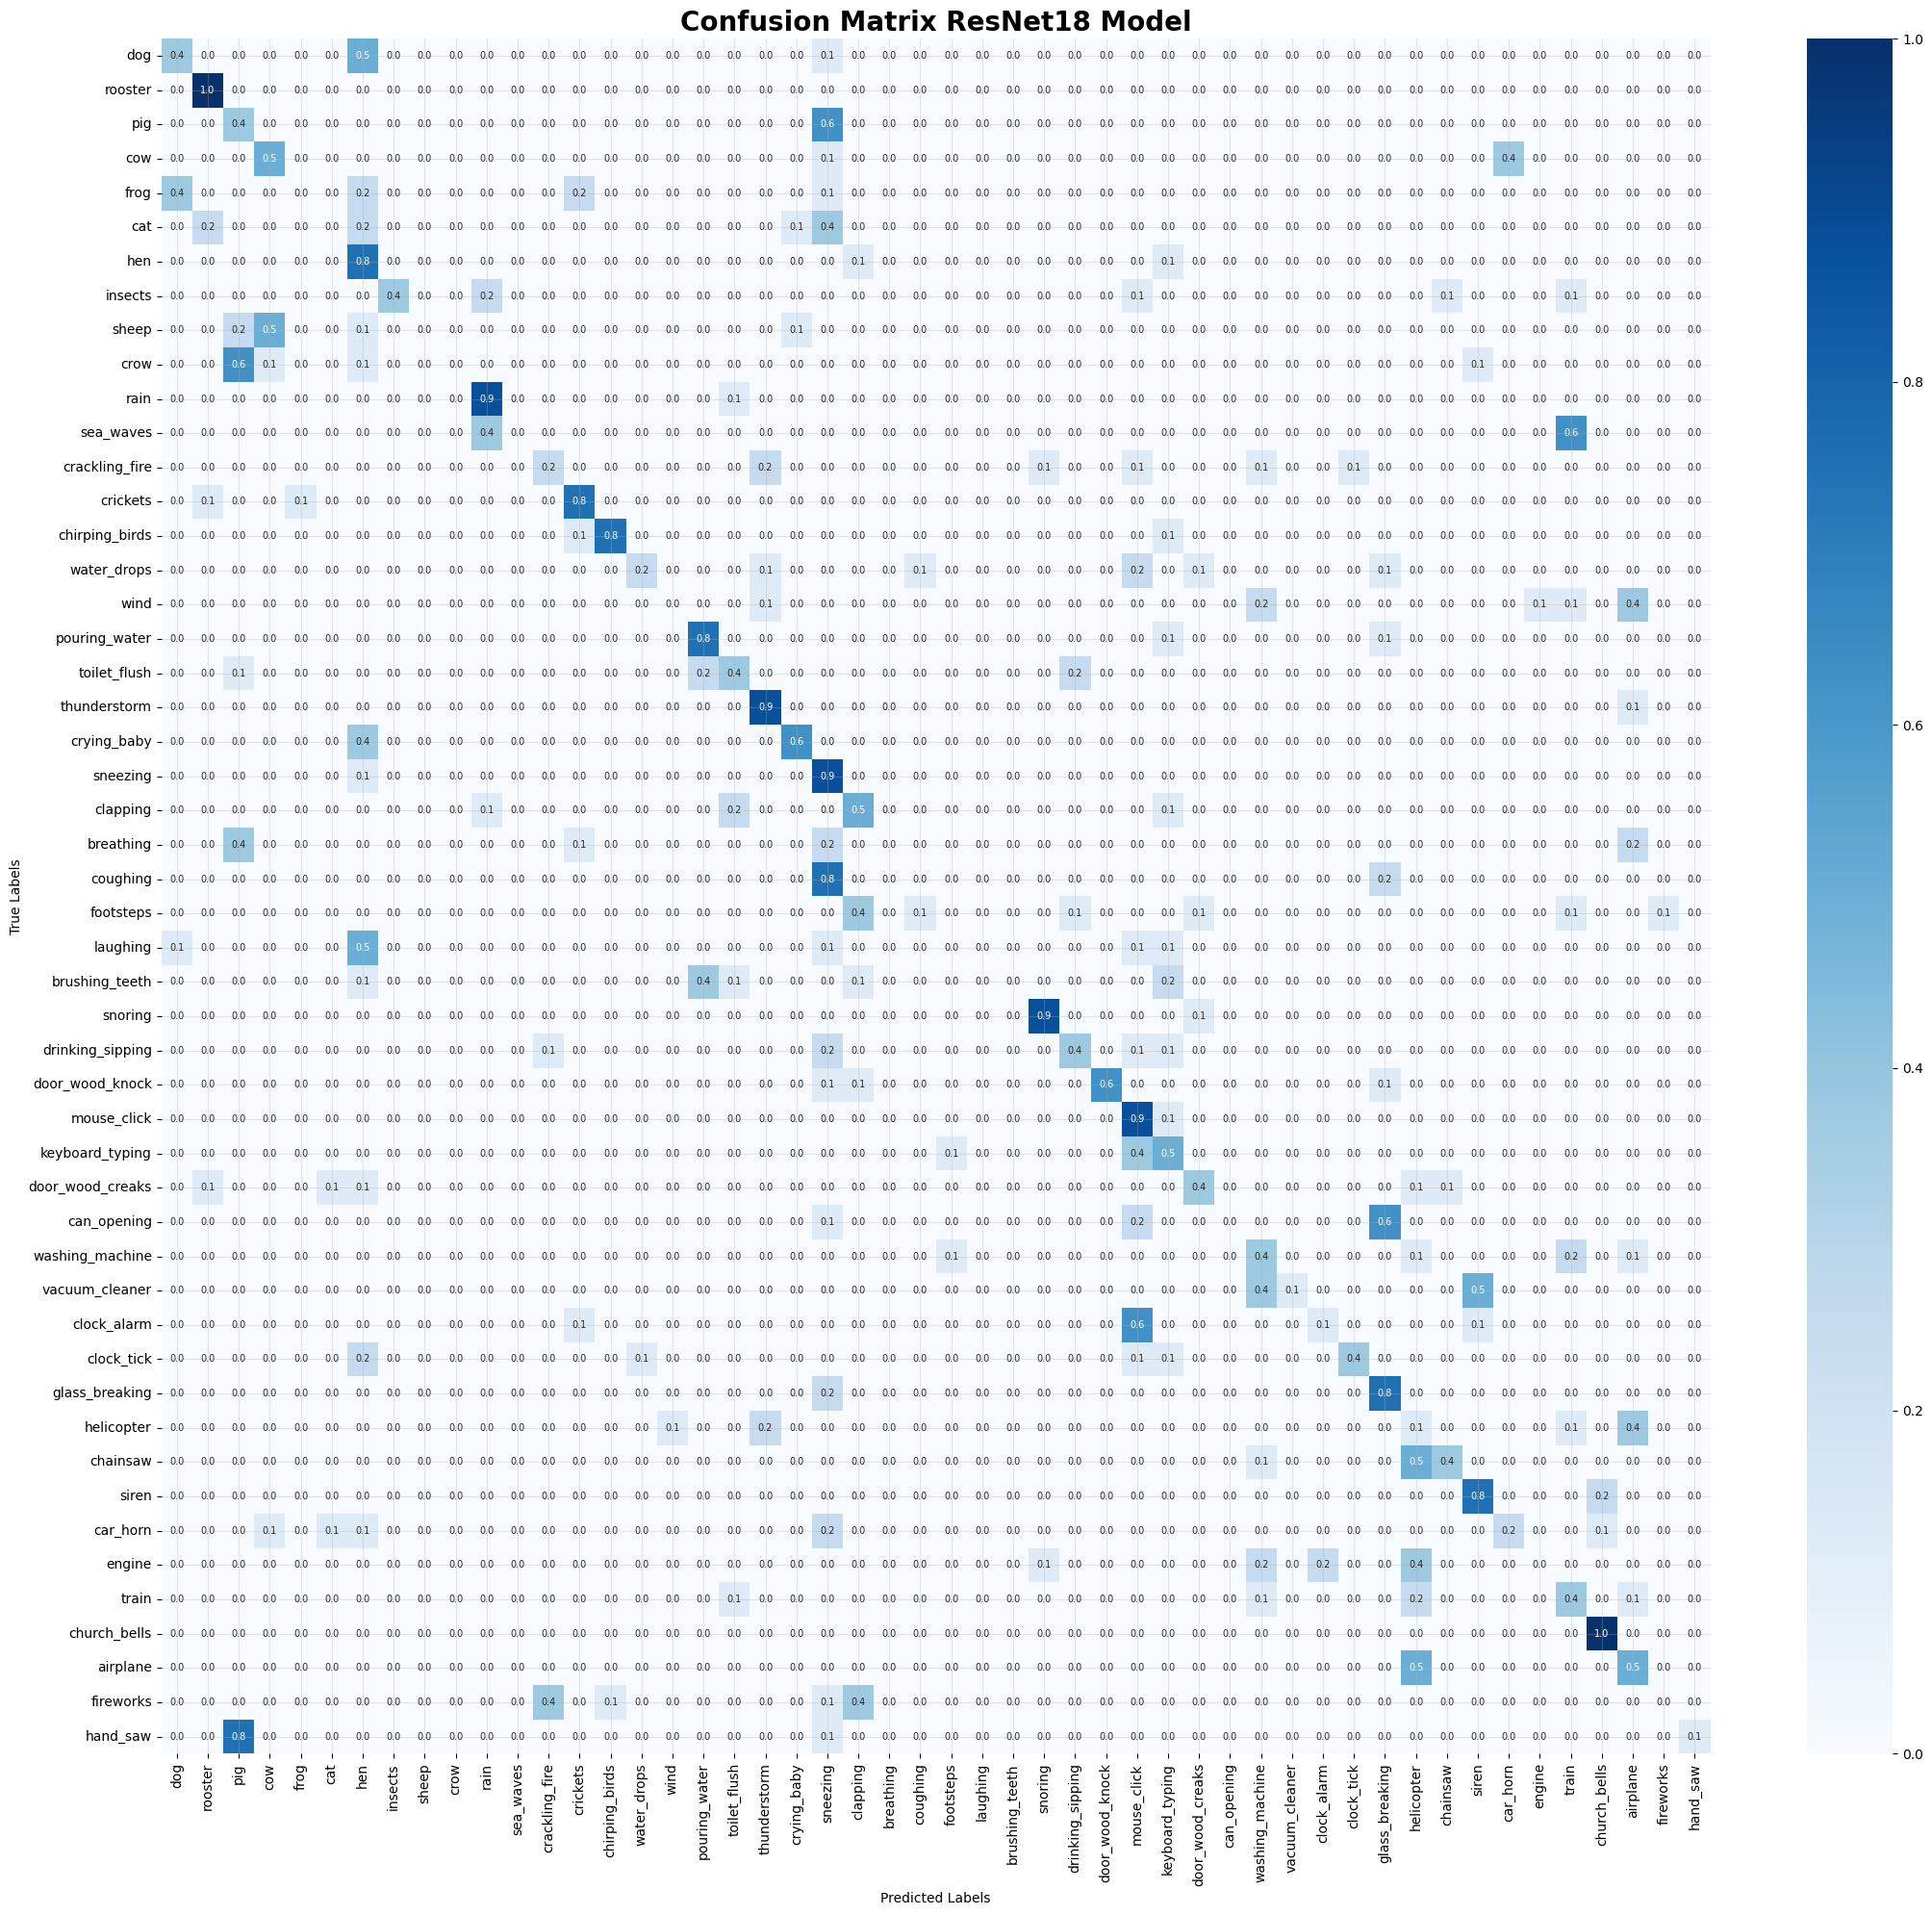

Complete saved file in ResNet18_metrics.json
Completed processing metrics for ResNet18
Completed extract embedding from penultimate layer of ResNet18 model
Embeddings saved to benchmark_embeddings_resnet18.csv (Ukuran: (400, 512))
RSM saved to rsm_cosine_resnet18.csv (Ukuran: (400, 400))


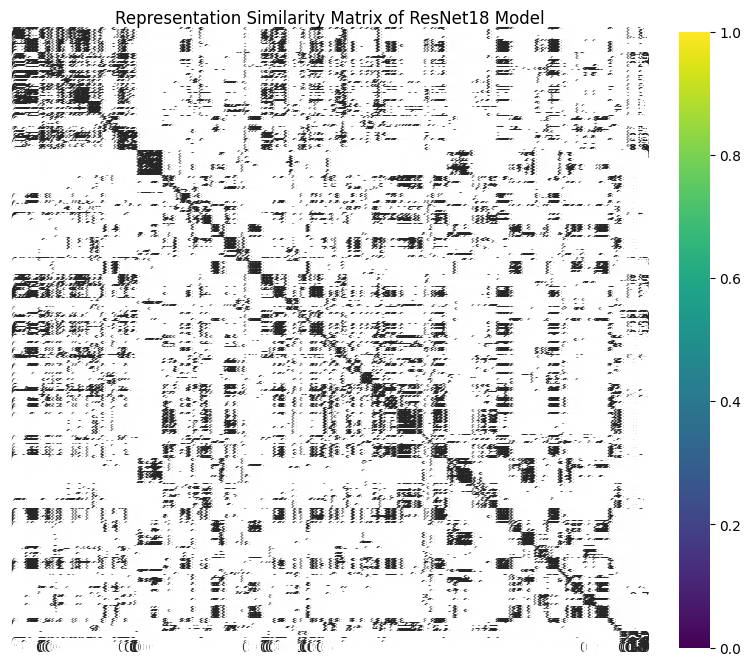

Heatmap saved to rsm_heatmap_resnet18.png
Completed process of RSM calculation for ResNet18 model
Generating visualisation for ResNet18
Completed visualisation for ResNet18


In [113]:
# Overall Evaluation
models_config = [
    {
        'name': 'CRNN',
        'class': CRNN,
        'path':'CRNN_best_model.pth',
        'lr': 0.001,
        'epochs':3,
        'args': {'input_size': 64, 'hidden_size': 128, 'num_layers': 2, 'num_classes': 50}
    },
    {
        'name': 'ResNet18',
        'class': ResNet18,
        'path': 'ResNet18_best_model.pth',
        'lr': 0.001,
        'epochs':3,
        'args': {'num_classes': 50, 'pretrained': True}
    }
]

for model_info in models_config:
    # default value
    f1 = 0.0
    best_epoch = 0
    current_best_val_acc = 0.0

    # Panggil kelas
    curr_model = model_info['class'](**model_info['args']).to(device)
    try:
        curr_model.load_state_dict(torch.load(model_info['path'], map_location=device))

        # Evaluasi/testing
        loss, acc, all_preds, all_labels = evaluate(curr_model, test_loader, criterion, device)

        # Classification Report
        print('\nClassification Report:')
        report = classification_report(all_labels, all_preds, output_dict=True)
        f1 = report['weighted avg']['f1-score']

        # Print results
        print(f"Model: {model_info['name']}")
        print(f"Loss : {loss:.4f}")
        print(f"Accuracy: {acc:.2f}%")
        print(f"F1-score: {f1:.2f}")
        print(classification_report(all_labels, all_preds))

        # Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)
        CMVis(cm, df.sort_values('target')['category'].unique(), model_info['name'])

        # Find the best epoch
        if model_info['name'] in all_history:
            val_acc_history = all_history[model_info['name']]['val_acc']
            if val_acc_history:
                best_val_acc_overall = max(val_acc_history)
                best_epoch = val_acc_history.index(best_val_acc_overall) + 1
            else:
                best_epoch = 0 # kalau tidak terekam di validasi
        else:
            best_epoch = 0 # kalau tida ada di history

    except FileNotFoundError:
        print(f"Error: File {model_info['path']} tidak ditemukan.")
    except Exception as e:
        print(f"Error saat evaluasi {model_info['name']}: {e}")

    # Save to metrics.json
    metrics(model_info['name'], acc, f1, best_epoch, curr_model, test_loader, device)
    print(f"Completed processing metrics for {model_info['name']}")

    # Extract embeddings
    embeddings, _ = extract_embedding(curr_model, benchmark_loader, model_info['name'], device)
    print(f"Completed extract embedding from penultimate layer of {model_info['name']} model")

    # Representation Similarity Analysis
    process_and_save_rsm(embeddings, model_info['name'])
    print(f"Completed process of RSM calculation for {model_info['name']} model")

    # Saliency/Attention
    print(f"Generating visualisation for {model_info['name']}")
    sal_attn_visualization(curr_model, benchmark_loader, model_info['name'], device)
    print(f"Completed visualisation for {model_info['name']}")

    # Clear memory
    del curr_model
    torch.cuda.empty_cache()



Classification Report:
Model: ViTAudio
Loss : 3.8397
Accuracy: 4.75%
F1-score: 0.01
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.00      0.00      0.00         8
           2       0.00      0.00      0.00         8
           3       0.00      0.00      0.00         8
           4       0.04      0.62      0.08         8
           5       0.00      0.00      0.00         8
           6       0.00      0.00      0.00         8
           7       0.00      0.00      0.00         8
           8       0.00      0.00      0.00         8
           9       0.00      0.00      0.00         8
          10       0.00      0.00      0.00         8
          11       0.00      0.00      0.00         8
          12       0.00      0.00      0.00         8
          13       0.00      0.00      0.00         8
          14       0.00      0.00      0.00         8
          15       0.00      0.00      0.00       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

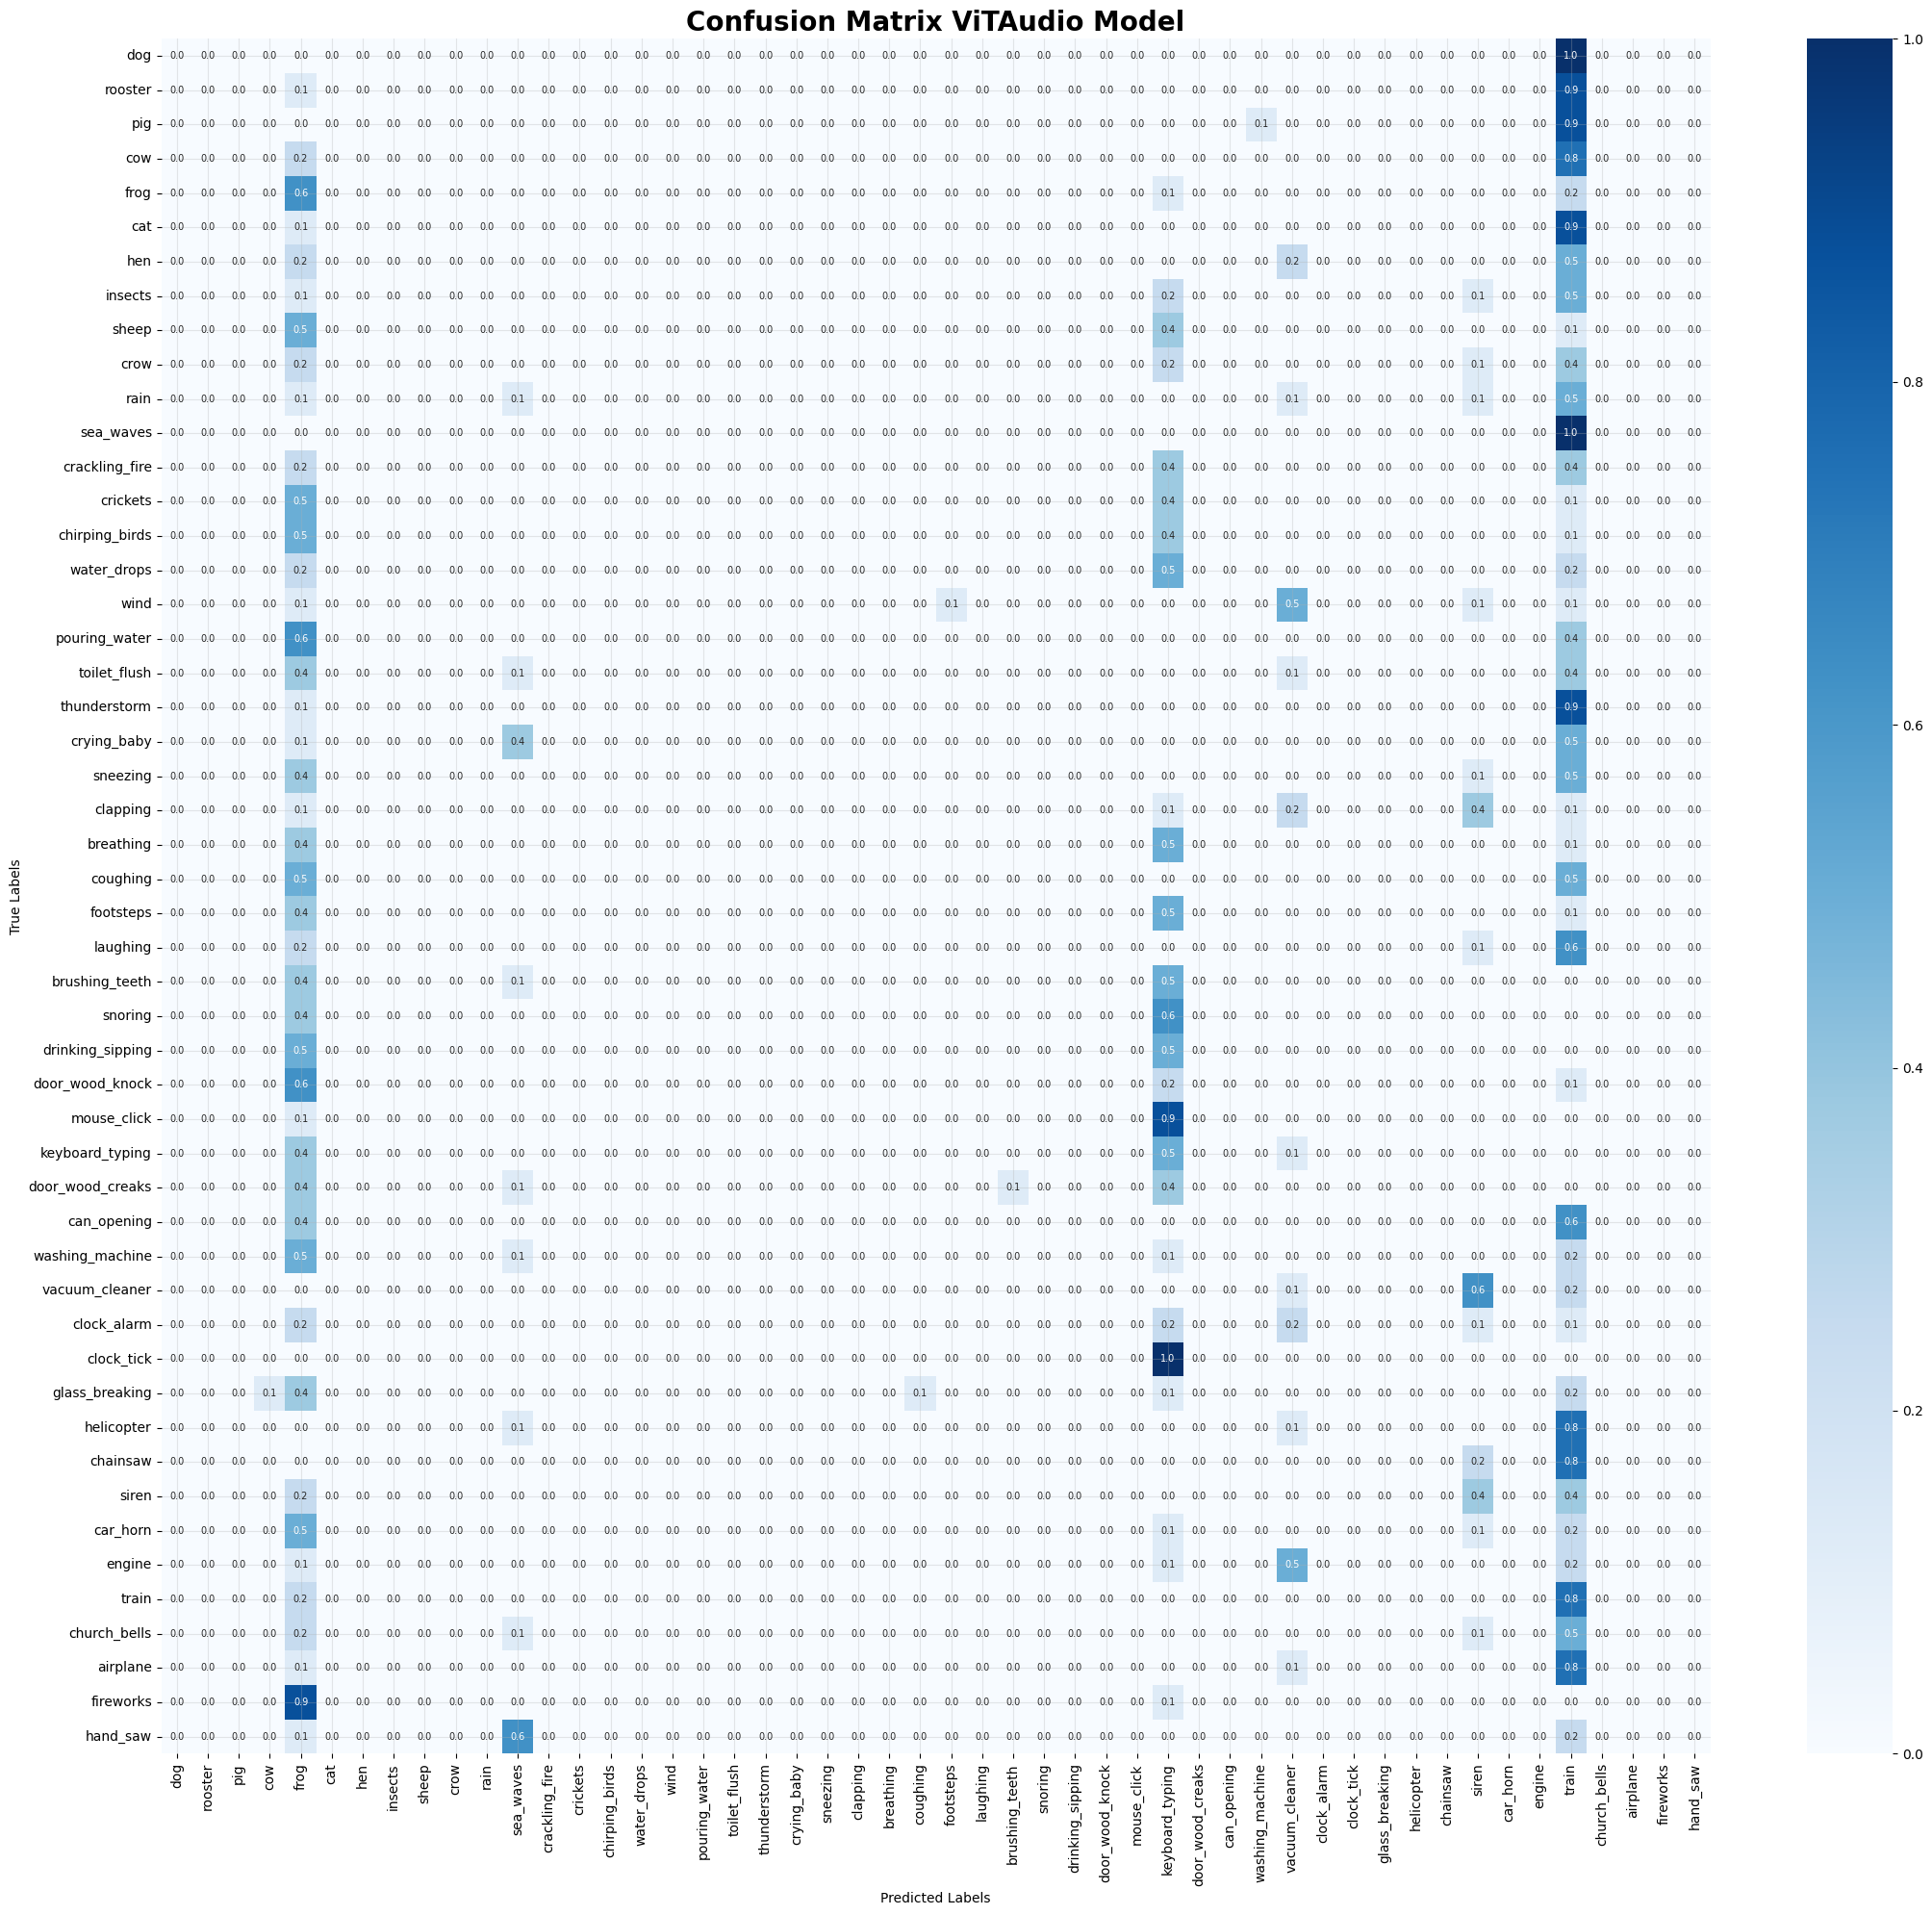

Complete saved file in ViTAudio_metrics.json
Completed processing metrics for ViTAudio
Completed extract embedding from penultimate layer of ViTAudio model
Embeddings saved to benchmark_embeddings_vitaudio.csv (Ukuran: (400, 768))
RSM saved to rsm_cosine_vitaudio.csv (Ukuran: (400, 400))


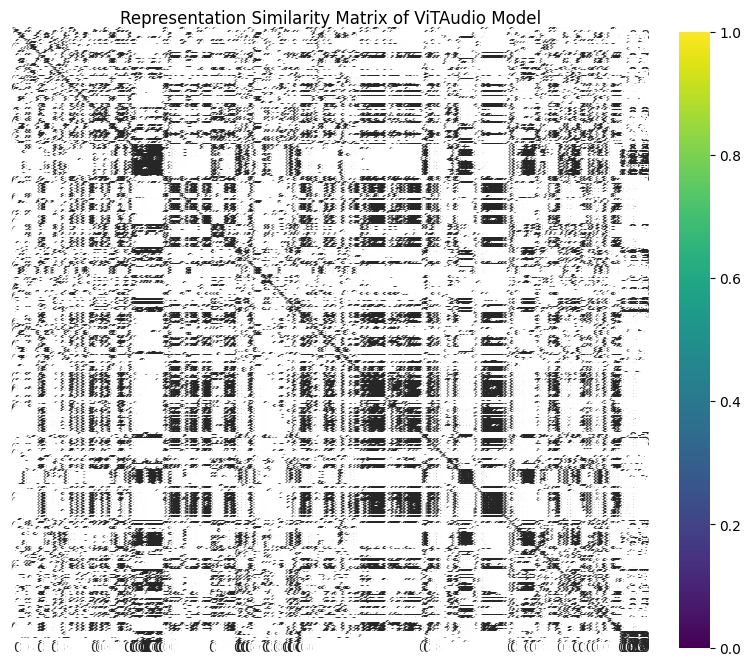

Heatmap saved to rsm_heatmap_vitaudio.png
Completed process of RSM calculation for ViTAudio model
Generating visualisation for ViTAudio
Completed visualisation for ViTAudio


In [114]:
vit_config = {
        'name': 'ViTAudio',
        'class': ViTAudio,
        'path':'vit_best_model.pth',
        'args': {'num_classes': 50, 'pretrained': True}
    }

# default value
f1 = 0.0
best_epoch = 0
current_best_val_acc = 0.0

# Ambil bobot dari path
try:
    vit_model = vit_config['class'](**vit_config['args']).to(device)
    vit_model.load_state_dict(torch.load(vit_config['path'], map_location=device))

    # Evaluasi/testing
    loss, acc, all_preds, all_labels = evaluate(vit_model, test_loader_vit, criterion, device)

    # Classification Report
    print('\nClassification Report:')
    report = classification_report(all_labels, all_preds, output_dict=True)
    f1 = report['weighted avg']['f1-score']

    # Print results
    print(f"Model: {vit_config['name']}")
    print(f"Loss : {loss:.4f}")
    print(f"Accuracy: {acc:.2f}%")
    print(f"F1-score: {f1:.2f}")
    print(classification_report(all_labels, all_preds))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    CMVis(cm, df.sort_values('target')['category'].unique(), vit_config['name'])

    # Find the best epoch
    if 'val_acc' in vit_history and len(vit_history['val_acc']) > 0:
        val_acc_list = vit_history['val_acc']
        best_val_acc_overall = max(val_acc_list)
        best_epoch = val_acc_list.index(best_val_acc_overall) + 1
    else:
        best_epoch = 0

except FileNotFoundError:
    print(f"Error: File {vit_config['path']} tidak ditemukan.")
except Exception as e:
    print(f"Error saat evaluasi {vit_config['name']}: {e}")

# Save to metrics.json
metrics(vit_config['name'], acc, f1, best_epoch, vit_model, test_loader_vit, device)
print(f"Completed processing metrics for {vit_config['name']}")

# Extract embeddings
embeddings, _ = extract_embedding(vit_model, benchmark_loader_vit, vit_config['name'], device)
print(f"Completed extract embedding from penultimate layer of {vit_config['name']} model")

# Representation Similarity Analysis
process_and_save_rsm(embeddings, vit_config['name'])
print(f"Completed process of RSM calculation for {vit_config['name']} model")

# Saliency/Attention
print(f"Generating visualisation for {vit_config['name']}")
sal_attn_visualization(vit_model, benchmark_loader_vit, vit_config['name'], device)
print(f"Completed visualisation for {vit_config['name']}")

In [116]:
!ls -R /kaggle/working

/kaggle/working:
 0_crnn_saliency.png	    6_vitaudio_saliency.png
 0_resnet18_saliency.png    7_crnn_saliency.png
 0_vitaudio_saliency.png    7_resnet18_saliency.png
 10_crnn_saliency.png	    7_vitaudio_saliency.png
 10_resnet18_saliency.png   8_crnn_saliency.png
 10_vitaudio_saliency.png   8_resnet18_saliency.png
 11_crnn_saliency.png	    8_vitaudio_saliency.png
 11_resnet18_saliency.png   9_crnn_saliency.png
 11_vitaudio_saliency.png   9_resnet18_saliency.png
 12_crnn_saliency.png	    9_vitaudio_saliency.png
 12_resnet18_saliency.png   benchmark_embeddings_crnn.csv
 12_vitaudio_saliency.png   benchmark_embeddings_resnet18.csv
 13_vitaudio_saliency.png   benchmark_embeddings_vitaudio.csv
 14_vitaudio_saliency.png   CRNN_best_model.pth
 15_vitaudio_saliency.png   CRNN_confusion_matrix.png
 16_vitaudio_saliency.png   CRNN_metrics.json
 17_vitaudio_saliency.png   CRNN_train_val_curve.png
 18_vitaudio_saliency.png   hasil.zip
 19_vitaudio_saliency.png   ResNet18_best_model.pth
 1_crnn_sal

In [117]:
!zip -r hasil.zip /kaggle/working/

updating: kaggle/working/ (stored 0%)
updating: kaggle/working/19_vitaudio_saliency.png (deflated 1%)
updating: kaggle/working/vit_best_model.pth (deflated 7%)
updating: kaggle/working/ViTAudio_confusion_matrix.png (deflated 28%)
updating: kaggle/working/rsm_heatmap_crnn.png (deflated 12%)
updating: kaggle/working/15_vitaudio_saliency.png (deflated 2%)
updating: kaggle/working/11_vitaudio_saliency.png (deflated 0%)
updating: kaggle/working/3_vitaudio_saliency.png (deflated 1%)
updating: kaggle/working/CRNN_train_val_curve.png (deflated 4%)
updating: kaggle/working/rsm_cosine_crnn.csv (deflated 58%)
updating: kaggle/working/rsm_cosine_vitaudio.csv (deflated 58%)
updating: kaggle/working/CRNN_confusion_matrix.png (deflated 28%)
updating: kaggle/working/benchmark_embeddings_crnn.csv (deflated 58%)
updating: kaggle/working/saliency_vitaudio/ (stored 0%)
updating: kaggle/working/CRNN_best_model.pth (deflated 8%)
updating: kaggle/working/14_vitaudio_saliency.png (deflated 1%)
updating: kaggl